# **Feature Engineering Notebook**
In this notebook, I will be doing feature engineering and introduce new features as required to help my model train better.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from os import path
path_train = '/content/drive/MyDrive/Colab_Notebooks/predictive_maintenance_engine/data/raw/train_FD001.txt'
path_test = '/content/drive/MyDrive/Colab_Notebooks/predictive_maintenance_engine/data/raw/test_FD001.txt'
path_rul = '/content/drive/MyDrive/Colab_Notebooks/predictive_maintenance_engine/data/raw/RUL_FD001.txt'

In [ ]:
columns = ['engine_id', 'cycle']
columns += [f'operational_setting_{i}' for i in range(1,4)]
columns += [f'sensors_{i}' for i in range(1,22)]

In [ ]:
train_df_fd001 = pd.read_csv(path_train, sep = '\s+', header = None, names = columns)
test_df_fd001 = pd.read_csv(path_test, sep = '\s+', header = None, names = columns)
RUL_df_fd001 = pd.read_csv(path_rul, sep = '\s+', header = None, names = ['RUL'])

In [ ]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_12,sensors_13,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
test_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_12,sensors_13,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [ ]:
RUL_df_fd001.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [ ]:
engine_lifetime = train_df_fd001.groupby('engine_id')['cycle'].max()

In [ ]:
# Vectorization concept
train_df_fd001['RUL'] = train_df_fd001['engine_id'].map(engine_lifetime) - train_df_fd001['cycle']
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_13,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [ ]:
# Piecewise RUL
train_df_fd001['RUL'] = train_df_fd001['RUL'].clip(upper=125)
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_13,sensors_14,sensors_15,sensors_16,sensors_17,sensors_18,sensors_19,sensors_20,sensors_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


In [ ]:
# From previous EDA notebook
useful_sensors = ['sensors_2','sensors_3','sensors_4','sensors_7','sensors_8','sensors_9',
                  'sensors_11','sensors_12','sensors_13','sensors_14','sensors_15',
                  'sensors_17','sensors_20','sensors_21']

dropped_sensors = ['sensors_1','sensors_5','sensors_6','sensors_10','sensors_16',
                   'sensors_18','sensors_19']

op_settings = ['operational_setting_1','operational_setting_2','operational_setting_3']

# **Rolling Statistics**

In [ ]:
eng1 = train_df_fd001[train_df_fd001['engine_id'] == 1].copy()
eng1['s7_rmean_10'] = eng1['sensors_7'].rolling(window = 10, min_periods = 1).mean()
eng1['s7_rstd_10'] = eng1['sensors_7'].rolling(window = 10, min_periods = 1).std()

eng1[['cycle', 'sensors_7', 's7_rmean_10', 's7_rstd_10']].head(12)

,cycle,sensors_7,s7_rmean_10,s7_rstd_10
0,1,554.36,554.360000,NaN
1,2,553.75,554.055000,0.431335
2,3,554.26,554.123333,0.327159
3,4,554.45,554.205000,0.313103
4,5,554.00,554.164000,0.286234
5,6,554.67,554.248333,0.328963
6,7,554.34,554.261429,0.302293
7,8,553.85,554.210000,0.315414
8,9,553.69,554.152222,0.342191
9,10,553.59,554.096000,0.368366


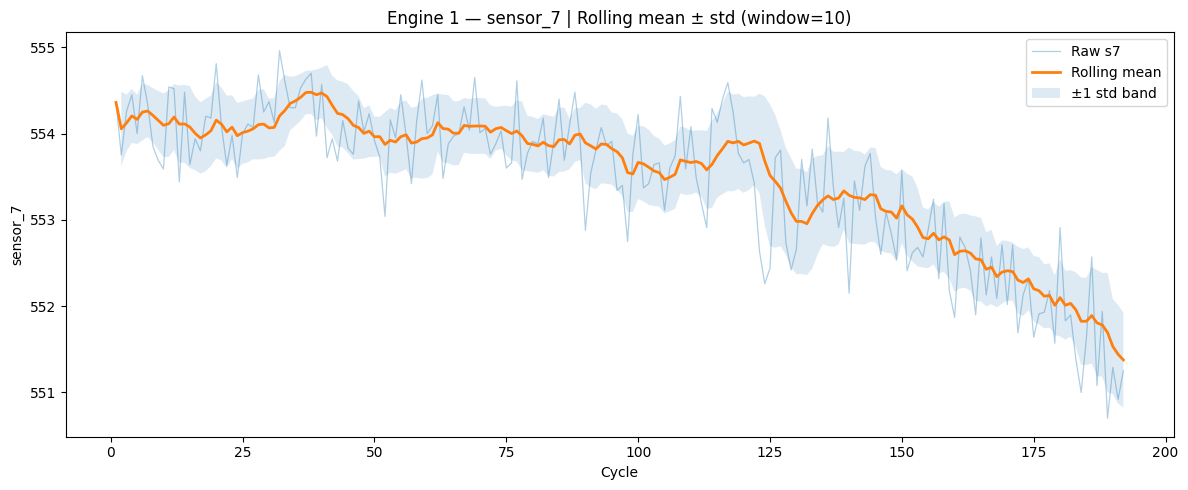

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(eng1['cycle'], eng1['sensors_7'], alpha=0.35, linewidth=0.9, label='Raw s7')
ax1.plot(eng1['cycle'], eng1['s7_rmean_10'], linewidth=2, label='Rolling mean')
ax1.fill_between(eng1['cycle'],
                 eng1['s7_rmean_10'] - eng1['s7_rstd_10'],
                 eng1['s7_rmean_10'] + eng1['s7_rstd_10'],
                 alpha=0.15, label='±1 std band')

ax1.set_xlabel('Cycle')
ax1.set_ylabel('sensor_7')
ax1.set_title('Engine 1 — sensor_7 | Rolling mean ± std (window=10)')
ax1.legend()
plt.tight_layout()
plt.show()

**From above plot, we can see that the thick orange line(rolling mean) shows downward trend as the cycle of the engine goes on increasing. Also, we can see that there's a sharp decline in the sensor 7 reading around 120 cycles and it declines rapidly compare to the first half where the engine is healthy. Finally, the std band width is almost consistent over the entire cycles which tells that there's no variability on sensor 7 and here mean is the major factor to observe the degrading trend.**

In [ ]:
# Now, I am going to apply rolling feature to all the sensors of all engines at once after testing
# that thing with just one sensor-7 above.

def rolling_feature(df):
  window_sizes = [5, 10, 20, 30]      # I am going to try for multiple window cycles to get a clear picture of the sensors
  for sensor in useful_sensors:
    for size in window_sizes:
      df[f'{sensor}_rmean_{size}'] = df.groupby('engine_id')[sensor].transform(lambda x:x.rolling(size, min_periods = 1).mean())
      df[f'{sensor}_rstd_{size}'] = df.groupby('engine_id')[sensor].transform(lambda x:x.rolling(size, min_periods = 1).std())
      df[f'{sensor}_rmin_{size}'] = df.groupby('engine_id')[sensor].transform(lambda x:x.rolling(size, min_periods = 1).min())
      df[f'{sensor}_rmax_{size}'] = df.groupby('engine_id')[sensor].transform(lambda x:x.rolling(size, min_periods = 1).max())

  return df

train_df_fd001 = rolling_feature(train_df_fd001)

In [ ]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_21_rmin_10,sensors_21_rmax_10,sensors_21_rmean_20,sensors_21_rstd_20,sensors_21_rmin_20,sensors_21_rmax_20,sensors_21_rmean_30,sensors_21_rstd_30,sensors_21_rmin_30,sensors_21_rmax_30
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,23.4190,23.4190,23.419000,NaN,23.4190,23.4190,23.419000,NaN,23.4190,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,23.4190,23.4236,23.421300,0.003253,23.4190,23.4236,23.421300,0.003253,23.4190,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,23.3442,23.4236,23.395600,0.044573,23.3442,23.4236,23.395600,0.044573,23.3442,23.4236
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,23.3442,23.4236,23.390175,0.037977,23.3442,23.4236,23.390175,0.037977,23.3442,23.4236
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,23.3442,23.4236,23.393020,0.033498,23.3442,23.4236,23.393020,0.033498,23.3442,23.4236


# **Rolling Slope**

In [ ]:
useful_sensors

['sensors_2',
 'sensors_3',
 'sensors_4',
 'sensors_7',
 'sensors_8',
 'sensors_9',
 'sensors_11',
 'sensors_12',
 'sensors_13',
 'sensors_14',
 'sensors_15',
 'sensors_17',
 'sensors_20',
 'sensors_21']

In [ ]:
def calc_slope(y):
  x = np.arange(len(y))       # gives the positions in x-axis like [0,1,2,3,4.......,y-1]
  if len(y) < 2:
    return np.nan
  return np.polyfit(x, y, 1)[0]       # draws line at the points(obtained from x and y(sensor values) and then returns slope)

def rolling_slope(df):
  for sensor in useful_sensors:
    for size in [10, 20]:
      df[f'{sensor}_rslope_{size}'] = df.groupby('engine_id')[sensor].transform(lambda x:x.rolling(size, min_periods = 2).apply(calc_slope, raw = True))
  return df

train_df_fd001 = rolling_slope(train_df_fd001)

# I have use min_periods = 2 here because we need atleast 2 points to fit a line.
# raw = True will pass the window values as numpy array instead of series to calc_slope which makes np.polyfit work correctly and runs faster
# It only passes those values as array but later transform again convert them back into series and returns original dataframe.

In [ ]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_14_rslope_10,sensors_14_rslope_20,sensors_15_rslope_10,sensors_15_rslope_20,sensors_17_rslope_10,sensors_17_rslope_20,sensors_20_rslope_10,sensors_20_rslope_20,sensors_21_rslope_10,sensors_21_rslope_20
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,-7.130,-7.130,0.01230,0.01230,-8.637964e-14,-8.637964e-14,-0.060,-0.060,0.00460,0.00460
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,-2.695,-2.695,-0.00085,-0.00085,-1.000000e+00,-1.000000e+00,-0.055,-0.055,-0.03740,-0.03740
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,-1.263,-1.263,-0.01679,-0.01679,-2.000000e-01,-2.000000e-01,-0.059,-0.059,-0.02147,-0.02147
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,-0.730,-0.730,-0.00438,-0.00438,2.000000e-01,2.000000e-01,-0.044,-0.044,-0.00789,-0.00789


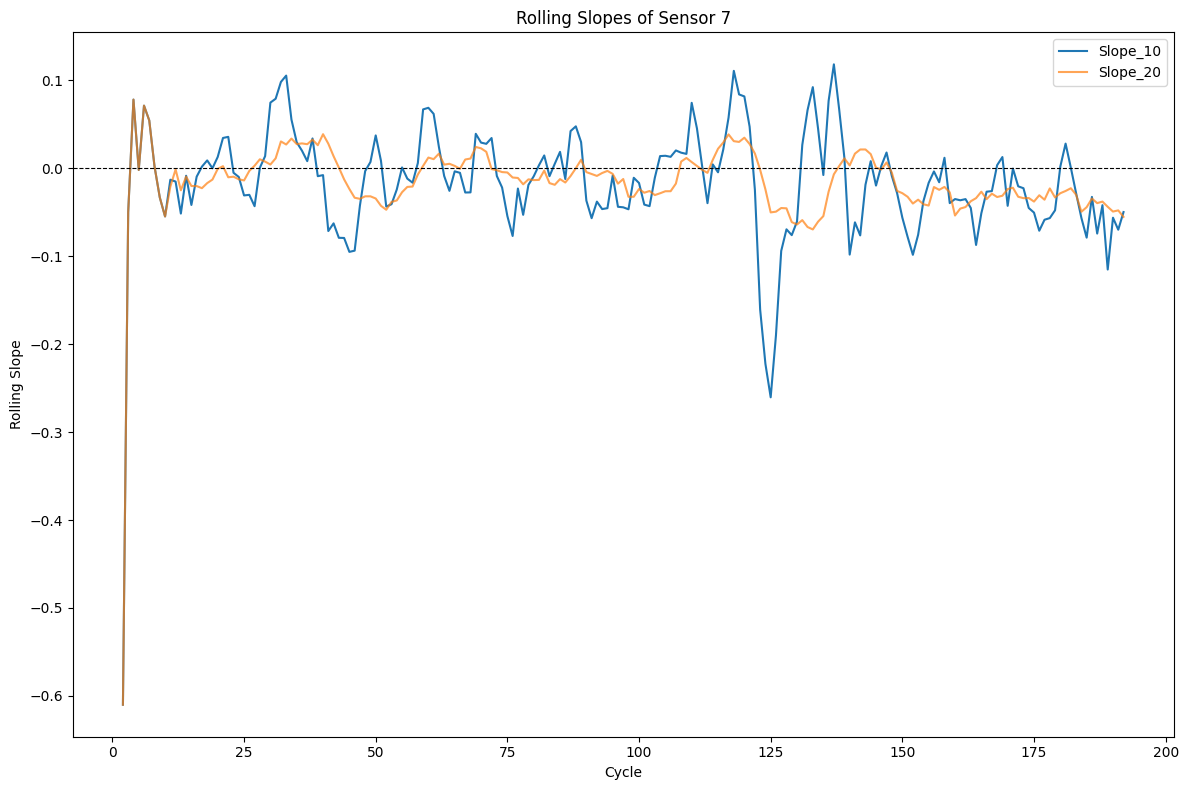

In [ ]:
engine_1 = train_df_fd001[train_df_fd001['engine_id'] == 1].copy()

fig, ax1 = plt.subplots(figsize = (12,8))
ax1.plot(engine_1['cycle'], engine_1['sensors_7_rslope_10'], linewidth = 1.5, label = 'Slope_10')
ax1.plot(engine_1['cycle'], engine_1['sensors_7_rslope_20'], linewidth = 1.5, label = 'Slope_20', alpha = 0.7)
ax1.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
ax1.set_xlabel('Cycle')
ax1.set_ylabel("Rolling Slope")
ax1.set_title('Rolling Slopes of Sensor 7', fontsize = 12)
ax1.legend()

plt.tight_layout()
plt.show()

**From the above plot, we see that the sensor 7 fluctuates near '0' with slight +0.1 to -0.1 change from (5 to 120) cycles which tells us that reading is consistent when the engine is healthy. But later after around 120 cycle, it rapidly drops down and keeps on dropping negatively below '0' which shows sensor 7 declines when engine is near its failure.**

**From (0 to 5 cycles we see a sharp negative line coming upto -0.6, that's due to NaN values at the starting phase and here's that doesn't matter and we can ignore that.**

# **EWMA**

In [49]:
def ewma(df):
  for sensor in useful_sensors:
    df[f'{sensor}_ewm'] = df.groupby('engine_id')[sensor].transform(lambda x:x.ewm(span = 10).mean())

  return df

train_df_fd001 = ewma(train_df_fd001)

In [50]:
train_df_fd001.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensors_1,sensors_2,sensors_3,sensors_4,sensors_5,...,sensors_8_ewm,sensors_9_ewm,sensors_11_ewm,sensors_12_ewm,sensors_13_ewm,sensors_14_ewm,sensors_15_ewm,sensors_17_ewm,sensors_20_ewm,sensors_21_ewm
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.060000,9046.190000,47.470000,521.660000,2388.020000,8138.620000,8.419500,392.000000,39.060000,23.419000
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.049000,9045.024000,47.481000,522.001000,2388.047500,8134.698500,8.426265,392.000000,39.027000,23.421530
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.061462,9048.206179,47.396179,522.169435,2388.040465,8134.108173,8.422862,391.196013,38.996047,23.390444
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.077453,9048.625847,47.308485,522.396946,2388.053490,8134.016527,8.404853,391.460891,38.957814,23.384993
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.072443,9050.498754,47.300308,522.337537,2388.049617,8133.954368,8.411900,391.902727,38.941217,23.390565


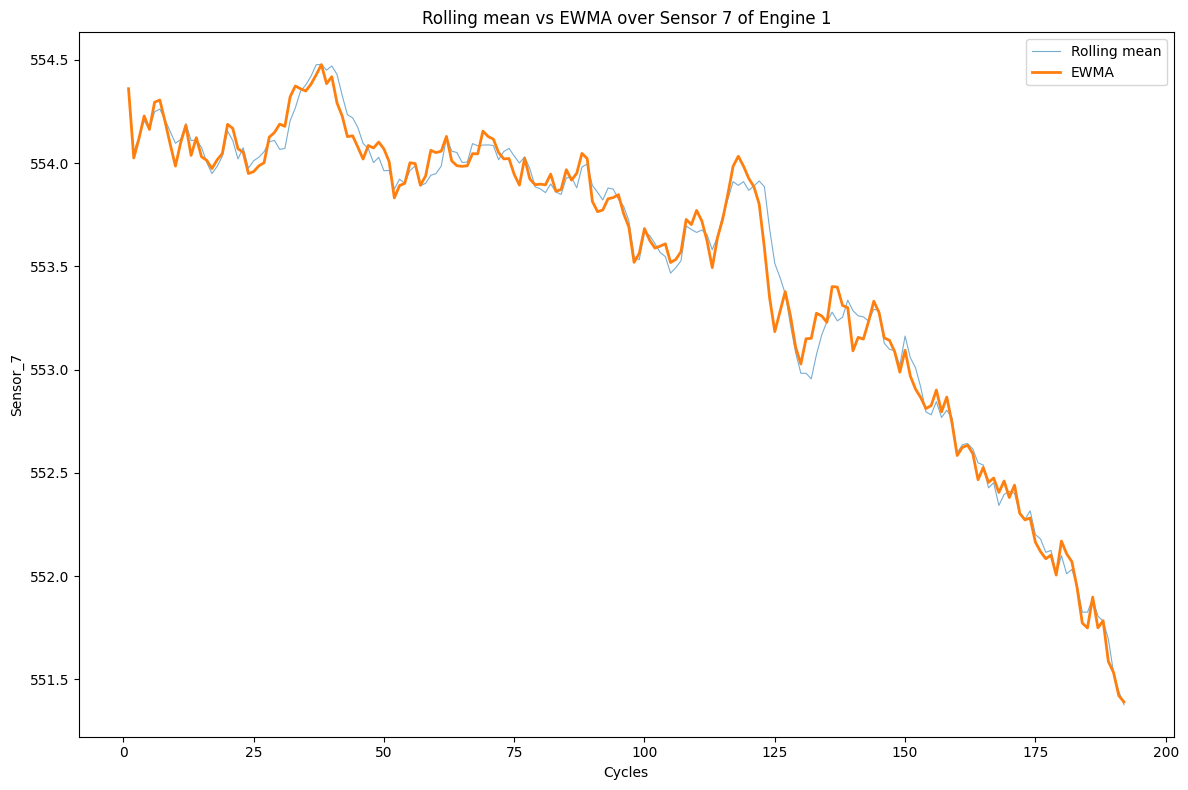

In [56]:
engine_1 = train_df_fd001[train_df_fd001['engine_id'] == 1].copy()

fig, ax = plt.subplots(figsize = (12, 8))
ax.plot(engine_1['cycle'], engine_1['sensors_7_rmean_10'], linewidth = 0.8, label = 'Rolling mean', alpha = 0.6)
ax.plot(engine_1['cycle'], engine_1['sensors_7_ewm'], linewidth = 2, label = 'EWMA')
ax.set_xlabel('Cycles')
ax.set_ylabel('Sensor_7')
ax.set_title('Rolling mean vs EWMA over Sensor 7 of Engine 1')
ax.legend()
plt.tight_layout()
plt.show()

**EWMA reacts faster to any changes than the rolling mean as we can see that from above plot because EWMA gives more importance to recent things than past. It is important because if an engine suddenly starts degrading faster, EWMA will pick it up before the rolling mean does.**